# Healthcare Readmission Prediction

## Project Overview

This notebook builds machine learning models to predict whether a patient will be readmitted within 30 days.

The target variable is:

- `readmitted_30d`
  - 0 = Not readmitted
  - 1 = Readmitted

This prediction task extends the previous exploratory analysis and SQL analysis by using patient characteristics to estimate readmission risk.

In [12]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/healthcare_readmission_analysis.csv"
)

df.head()

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,days_to_readmission,primary_drg,total_charges_usd,age_group,los_group
0,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,0,0,0,home_health,0,NaN,291,8589.79,65+,1-3 Days
1,P0000003,82,M,17.8,135,57,90,98.2,never,light,...,0,0,0,hospice,1,28.0,392,22628.17,65+,1-3 Days
2,P0000011,62,F,27.7,116,90,88,97.6,never,none,...,0,0,0,rehab,0,NaN,392,27565.97,50-64,8-14 Days
3,P0000014,72,F,38.1,124,91,90,98.7,current,light,...,0,0,0,home,0,NaN,194,10332.33,65+,4-7 Days
4,P0000040,84,M,27.3,155,75,81,98.7,never,light,...,0,0,0,rehab,0,NaN,470,2389.61,65+,1-3 Days


## 1. Dataset Overview

Before building machine learning models, we first check the size and structure of the processed dataset.

In [13]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (11001, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11001 entries, 0 to 11000
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  11001 non-null  object 
 1   age                         11001 non-null  int64  
 2   sex                         11001 non-null  object 
 3   bmi                         11001 non-null  float64
 4   systolic_bp                 11001 non-null  int64  
 5   diastolic_bp                11001 non-null  int64  
 6   heart_rate                  11001 non-null  int64  
 7   temperature_f               11001 non-null  float64
 8   smoking_status              11001 non-null  object 
 9   alcohol_use                 11001 non-null  object 
 10  exercise_level              11001 non-null  object 
 11  insurance_type              11001 non-null  object 
 12  charlson_index              11001 non-null  int64  
 13  dx_h

## 2. Target Variable Distribution

The target variable is `readmitted_30d`.

Because this is a binary classification problem, it is important to check whether the classes are balanced.

In [14]:
df["readmitted_30d"].value_counts()

readmitted_30d
0    9358
1    1643
Name: count, dtype: int64

In [15]:
df["readmitted_30d"].value_counts(normalize=True)

readmitted_30d
0    0.85065
1    0.14935
Name: proportion, dtype: float64

## 3. Feature Selection

For the first baseline model, we select clinical and demographic features that were identified as important during exploratory analysis.

Selected features:

- Age
- Charlson Comorbidity Index
- ICU Admission
- Chronic Kidney Disease
- Total Hospital Charges

In [16]:
features = [
    "age",
    "charlson_index",
    "icu_admission",
    "dx_chronic_kidney_disease",
    "total_charges_usd"
]

X = df[features]
y = df["readmitted_30d"]

X.head()

,age,charlson_index,icu_admission,dx_chronic_kidney_disease,total_charges_usd
0,75,1,0,0,8589.79
1,82,3,0,1,22628.17
2,62,2,0,1,27565.97
3,72,2,0,1,10332.33
4,84,0,0,0,2389.61


## 4. Train-Test Split

The dataset is split into training and testing sets.

- 80% training data
- 20% testing data

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (8800, 5)
Testing Set: (2201, 5)


## 5. Logistic Regression Model

Logistic Regression is a commonly used classification algorithm for binary outcomes.

In this project, the model is used to predict whether a patient will be readmitted within 30 days based on demographic and clinical characteristics.

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Libr

## 6. Model Evaluation

After training the Logistic Regression model, we evaluate its performance using accuracy and classification metrics.

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.8505224897773739


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1872
           1       0.00      0.00      0.00       329

    accuracy                           0.85      2201
   macro avg       0.43      0.50      0.46      2201
weighted avg       0.72      0.85      0.78      2201



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

## Logistic Regression Results

The Logistic Regression model achieved an accuracy of **85.05%**.

However, the classification report revealed that the model failed to correctly identify patients who were readmitted within 30 days. The recall score for the positive class (readmitted patients) was **0.00**.

This occurred because the dataset is imbalanced, with approximately **85% of patients not being readmitted** and only **15% being readmitted**. As a result, the model primarily predicted the majority class, which produced a high accuracy score but poor predictive performance for identifying readmitted patients.

These results demonstrate that accuracy alone is not sufficient for evaluating classification models on imbalanced datasets. Additional models and evaluation metrics are required to better identify high-risk patients.

## 7. Random Forest Classification

To improve prediction performance, a Random Forest classifier was trained and evaluated.

Random Forest can capture nonlinear relationships and interactions between variables more effectively than Logistic Regression.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7964561562925943


In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.85      0.93      0.89      1872
           1       0.12      0.06      0.08       329

    accuracy                           0.80      2201
   macro avg       0.48      0.49      0.48      2201
weighted avg       0.74      0.80      0.76      2201



## Random Forest Results

The Random Forest model achieved an accuracy of **79.65%**.

Although the overall accuracy was lower than Logistic Regression, the model was able to identify some readmitted patients, achieving a recall score of **0.06** for the positive class.

This suggests that Random Forest captured additional patterns in the data that Logistic Regression could not identify. However, the model still struggled to accurately predict readmissions due to class imbalance and limited predictive features.

Future improvements may include feature engineering, class balancing techniques, and hyperparameter tuning.

## 8. Feature Importance Analysis

To understand which variables contributed most to prediction performance, feature importance scores were extracted from the Random Forest model.

In [26]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

importance

,Feature,Importance
2,icu_admission,0.005073
3,dx_chronic_kidney_disease,0.007521
1,charlson_index,0.028439
0,age,0.190021
4,total_charges_usd,0.768947


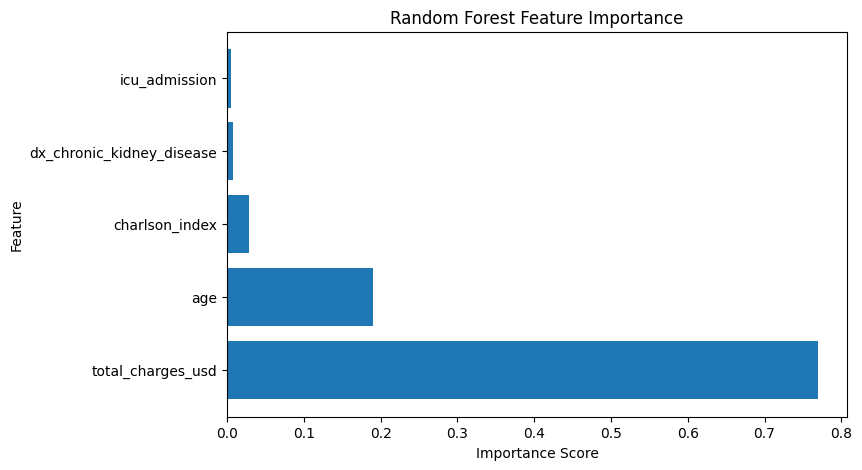

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

## Feature Importance Results

Feature importance analysis showed that **Total Hospital Charges** was the most influential predictor in the Random Forest model, followed by **Age** and **Charlson Comorbidity Index**.

Clinical indicators such as ICU admission status and Chronic Kidney Disease contributed less to the model's predictions.

These findings suggest that healthcare utilization measures, particularly hospital charges, may contain important information related to patient readmission risk.

# Conclusion

This project explored healthcare readmission prediction using machine learning models.

Key findings:

- Logistic Regression achieved high accuracy but failed to identify readmitted patients due to class imbalance.
- Random Forest was able to identify some readmitted patients and provided feature importance insights.
- Total hospital charges and age were the most influential predictors in the current model.
- Future work includes class balancing, feature engineering, and advanced ensemble methods.

## 9. Improved Model with Additional Features

To improve prediction performance, additional demographic, clinical, and hospitalization variables were included.

Class balancing and feature scaling were also applied to address data imbalance and improve model training.

In [27]:
features_v2 = [
    "age",
    "bmi",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "charlson_index",
    "dx_hypertension",
    "dx_type2_diabetes",
    "dx_heart_failure",
    "dx_chronic_kidney_disease",
    "icu_admission",
    "length_of_stay_days",
    "total_charges_usd"
]

X_v2 = df[features_v2]
y_v2 = df["readmitted_30d"]

In [28]:
from sklearn.model_selection import train_test_split

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_v2)
X_test_scaled = scaler.transform(X_test_v2)

In [30]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_balanced.fit(
    X_train_scaled,
    y_train_v2
)

lr_predictions = lr_balanced.predict(
    X_test_scaled
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(
    f"Balanced Logistic Regression Accuracy: {accuracy_score(y_test_v2, lr_predictions):.2%}"
)

print(
    classification_report(
        y_test_v2,
        lr_predictions
    )
)

Balanced Logistic Regression Accuracy: 60.38%
              precision    recall  f1-score   support

           0       0.89      0.61      0.72      1872
           1       0.21      0.58      0.30       329

    accuracy                           0.60      2201
   macro avg       0.55      0.59      0.51      2201
weighted avg       0.79      0.60      0.66      2201



## Improved Model Results

A balanced Logistic Regression model was trained using additional clinical features, feature scaling, and class weighting.

Although overall accuracy decreased to 60.38%, the model achieved a recall score of 0.58 for readmitted patients.

Compared with previous models, the balanced model was significantly more effective at identifying patients at risk of readmission.

These results highlight the importance of addressing class imbalance and selecting evaluation metrics beyond accuracy when developing healthcare prediction models.

## 10. Balanced Random Forest

A balanced Random Forest model was trained to address class imbalance while capturing nonlinear relationships between clinical variables.

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(
    X_train_v2,
    y_train_v2
)

rf_balanced_predictions = rf_balanced.predict(
    X_test_v2
)

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(
    f"Balanced RF Accuracy: {accuracy_score(y_test_v2, rf_balanced_predictions):.2%}"
)

print(
    classification_report(
        y_test_v2,
        rf_balanced_predictions
    )
)

Balanced RF Accuracy: 85.05%
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1872
           1       0.00      0.00      0.00       329

    accuracy                           0.85      2201
   macro avg       0.43      0.50      0.46      2201
weighted avg       0.72      0.85      0.78      2201



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

## Balanced Random Forest Results

A balanced Random Forest model was trained to improve prediction performance on the minority class.

However, the model predicted all observations as the majority class (not readmitted), resulting in a recall score of 0.00 for readmitted patients.

Despite using class weighting, the model was unable to effectively identify positive cases in this dataset.

This result highlights that class balancing alone does not guarantee improved performance and that model selection and feature engineering remain important considerations.

## 11. SMOTE + Logistic Regression

SMOTE was applied to address class imbalance by oversampling the minority class in the training data.

This approach creates synthetic examples of readmitted patients, allowing the model to learn patterns from a more balanced dataset.

In [41]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train_v2
)

smote_lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

smote_lr.fit(
    X_train_smote,
    y_train_smote
)

smote_predictions = smote_lr.predict(
    X_test_scaled
)

print(
    f"SMOTE Logistic Regression Accuracy: {accuracy_score(y_test_v2, smote_predictions):.2%}"
)

print(
    classification_report(
        y_test_v2,
        smote_predictions
    )
)

SMOTE Logistic Regression Accuracy: 59.97%
              precision    recall  f1-score   support

           0       0.88      0.61      0.72      1872
           1       0.20      0.54      0.29       329

    accuracy                           0.60      2201
   macro avg       0.54      0.58      0.51      2201
weighted avg       0.78      0.60      0.66      2201



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

## SMOTE Logistic Regression Results

SMOTE was applied to generate synthetic examples of readmitted patients and balance the training dataset.

However, the model achieved a recall score of 0.54, which was slightly lower than the Balanced Logistic Regression model (0.58).

These results suggest that class weighting alone was sufficient to address class imbalance in this dataset, and additional oversampling did not significantly improve prediction performance.

In [32]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        0.8505,
        0.7965,
        0.6038
    ],
    "Recall (Readmitted)": [
        0.00,
        0.06,
        0.58
    ]
})

comparison

,Model,Accuracy,Recall (Readmitted)
0,Logistic Regression,0.8505,0.00
1,Random Forest,0.7965,0.06
2,Balanced Logistic Regression,0.6038,0.58


## Model Comparison

The performance of multiple machine learning models was compared to evaluate their ability to identify patients at risk of 30-day readmission.

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Logistic Regression",
        "SMOTE Logistic Regression"
    ],
    "Accuracy": [
        0.8505,
        0.7965,
        0.6038,
        0.5997
    ],
    "Recall (Readmitted Patients)": [
        0.00,
        0.06,
        0.58,
        0.54
    ]
})

comparison

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Logistic Regression",
        "SMOTE Logistic Regression"
    ],
    "Accuracy": [
        0.8505,
        0.7965,
        0.6038,
        0.5997
    ],
    "Recall (Readmitted Patients)": [
        0.00,
        0.06,
        0.58,
        0.54
    ]
})

comparison

In [43]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Random Forest",
        "Balanced Logistic Regression",
        "SMOTE Logistic Regression"
    ],
    "Accuracy": [
        0.8505,
        0.7965,
        0.8505,
        0.6038,
        0.5997
    ],
    "Recall (Readmitted Patients)": [
        0.00,
        0.06,
        0.00,
        0.58,
        0.54
    ]
})

comparison

,Model,Accuracy,Recall (Readmitted Patients)
0,Logistic Regression,0.8505,0.00
1,Random Forest,0.7965,0.06
2,Balanced Random Forest,0.8505,0.00
3,Balanced Logistic Regression,0.6038,0.58
4,SMOTE Logistic Regression,0.5997,0.54


# Final Conclusion

This project analyzed healthcare readmission risk using exploratory data analysis, SQL, Tableau, and machine learning techniques.

Key findings include:

- Patients aged 65+ experienced the highest readmission rates.
- Readmission risk increased as Charlson Comorbidity Index increased.
- ICU admission and Chronic Kidney Disease were associated with higher readmission rates.
- Total hospital charges and age were identified as important predictive features.

Several machine learning models were evaluated:

- Logistic Regression achieved high accuracy but failed to identify readmitted patients.
- Random Forest provided limited improvement.
- Balanced Random Forest did not improve minority-class detection and predicted only the majority class.
- Balanced Logistic Regression achieved the best overall performance for identifying readmitted patients.
- SMOTE Logistic Regression produced similar results but did not outperform the balanced model.

The final model achieved a recall score of 0.58 for readmitted patients, demonstrating the importance of addressing class imbalance in healthcare prediction problems.

Future work may include additional feature engineering, hyperparameter tuning, and advanced ensemble methods such as XGBoost.